# Rec Center occupancy modeling

Predict 30-minute Rec Center occupancy during academic terms, handle export gaps without filling overnight closures, and recommend relatively quiet workout times.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

RNG_SEED = 42
np.random.seed(RNG_SEED)

BASE = Path.cwd()
if not (BASE / "ClassProject").exists() and (BASE / "processed").exists():
    # Running from ClassProject already
    PROCESSED_DIR = BASE / "processed"
else:
    # Running from repo root
    BASE = BASE / "ClassProject"
    PROCESSED_DIR = BASE / "processed"

PROCESSED_DIR, BASE

(PosixPath('/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/ClassProject/processed'),
 PosixPath('/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/ClassProject'))

In [10]:
rec_path = PROCESSED_DIR / "occuspace_30min_rec_center.csv"
terms_path = PROCESSED_DIR / "academic_terms.csv"

rec = pd.read_csv(rec_path)
terms = pd.read_csv(terms_path)

rec["Timestamp"] = pd.to_datetime(rec["Timestamp"])
rec["Date"] = pd.to_datetime(rec["Date"])
for col in ["classes_begin", "last_day_classes", "finals_begin", "finals_end"]:
    terms[col] = pd.to_datetime(terms[col])

rec = rec.sort_values("Timestamp").reset_index(drop=True)

rec.head()

,Location,Timestamp,Date,Day of Week,Week of Year,Time,Hour of Day,Average Occupancy,Average Utilization,Peak Occupancy,Peak Utilization,Capacity,Location Path,export_period,source_file,academic_year,term,term_phase,instruction_week
0,Rec Center,2023-05-13 06:00:00,2023-05-13,7,19,6:00:00 AM,6,5,0.02,6,0.03,220,Cal Poly > Rec Center,2023-05_to_2024-05,-30minExport-1May23-1May24.csv,2022-23,Spring,instruction,6
1,Rec Center,2023-05-13 06:30:00,2023-05-13,7,19,6:30:00 AM,6,5,0.02,6,0.03,220,Cal Poly > Rec Center,2023-05_to_2024-05,-30minExport-1May23-1May24.csv,2022-23,Spring,instruction,6
2,Rec Center,2023-05-13 07:00:00,2023-05-13,7,19,7:00:00 AM,7,5,0.02,6,0.03,220,Cal Poly > Rec Center,2023-05_to_2024-05,-30minExport-1May23-1May24.csv,2022-23,Spring,instruction,6
3,Rec Center,2023-05-13 07:30:00,2023-05-13,7,19,7:30:00 AM,7,7,0.03,8,0.04,220,Cal Poly > Rec Center,2023-05_to_2024-05,-30minExport-1May23-1May24.csv,2022-23,Spring,instruction,6
4,Rec Center,2023-05-13 08:00:00,2023-05-13,7,19,8:00:00 AM,8,48,0.22,64,0.29,220,Cal Poly > Rec Center,2023-05_to_2024-05,-30minExport-1May23-1May24.csv,2022-23,Spring,instruction,6


In [11]:
print(f"Rows: {len(rec):,}")
print(f"Date range: {rec['Date'].min().date()} → {rec['Date'].max().date()}")
print("Columns:", list(rec.columns))

Rows: 22,744
Date range: 2023-05-13 → 2026-04-15
Columns: ['Location', 'Timestamp', 'Date', 'Day of Week', 'Week of Year', 'Time', 'Hour of Day', 'Average Occupancy', 'Average Utilization', 'Peak Occupancy', 'Peak Utilization', 'Capacity', 'Location Path', 'export_period', 'source_file', 'academic_year', 'term', 'term_phase', 'instruction_week']


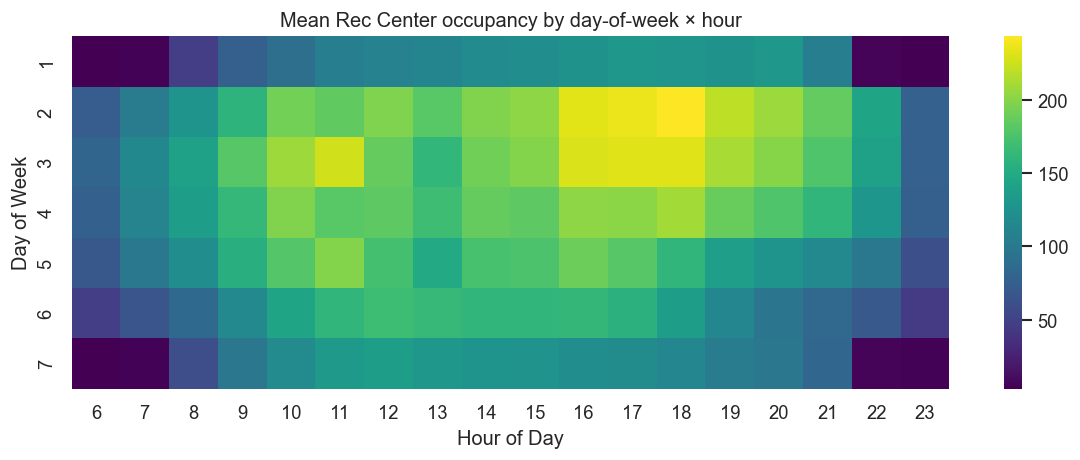

In [12]:
# Quick heatmap of mean occupancy by day-of-week × hour
heat = rec.groupby(["Day of Week", "Hour of Day"])["Average Occupancy"].mean().unstack()
plt.figure(figsize=(10, 4))
sns.heatmap(heat, cmap="viridis")
plt.title("Mean Rec Center occupancy by day-of-week × hour")
plt.ylabel("Day of Week")
plt.xlabel("Hour of Day")
plt.tight_layout()

## 2. Gap detection and selective imputation (multi-day only)

Classify gaps between consecutive timestamps. We **do not** fill overnight closing gaps (up to 8 hours), but we do impute missing operating slots inside larger export or calendar gaps.

In [13]:
from datetime import timedelta

GAP_THRESHOLD = pd.Timedelta(hours=8)

# Unique, sorted timestamps
uniq_ts = rec["Timestamp"].drop_duplicates().sort_values().reset_index(drop=True)

deltas = uniq_ts.diff()

big_gaps = deltas[deltas > GAP_THRESHOLD]
print(f"Total gaps > 30 min: {(deltas > pd.Timedelta(minutes=30)).sum():,}")
print(f"Overnight-ish gaps (30 min – 8h]: {(deltas > pd.Timedelta(minutes=30)).sum() - len(big_gaps):,}")
print(f"Export / calendar gaps (>8h): {len(big_gaps):,}\n")

print("Sample big gaps:")
for idx, delta in big_gaps.head(10).items():
    print(f"  after {uniq_ts[idx-1]}  →  gap {delta}  → next {uniq_ts[idx]}")

Total gaps > 30 min: 632
Overnight-ish gaps (30 min – 8h]: 612
Export / calendar gaps (>8h): 20

Sample big gaps:
  after 2023-06-09 23:30:00  →  gap 2 days 06:30:00  → next 2023-06-12 06:00:00
  after 2023-06-16 23:30:00  →  gap 96 days 06:30:00  → next 2023-09-21 06:00:00
  after 2023-12-08 23:30:00  →  gap 2 days 06:30:00  → next 2023-12-11 06:00:00
  after 2023-12-15 23:30:00  →  gap 23 days 06:30:00  → next 2024-01-08 06:00:00
  after 2024-03-15 23:30:00  →  gap 2 days 06:30:00  → next 2024-03-18 06:00:00
  after 2024-03-22 23:30:00  →  gap 10 days 06:30:00  → next 2024-04-02 06:00:00
  after 2024-05-01 23:30:00  →  gap 30 days 06:30:00  → next 2024-06-01 06:00:00
  after 2024-06-07 23:30:00  →  gap 2 days 06:30:00  → next 2024-06-10 06:00:00
  after 2024-06-14 23:30:00  →  gap 100 days 06:30:00  → next 2024-09-23 06:00:00
  after 2024-10-15 23:30:00  →  gap 0 days 08:30:00  → next 2024-10-16 08:00:00


In [14]:
def operating_range(day: pd.Timestamp) -> pd.DatetimeIndex:
    """Return 30-min operating slots for a given calendar day (06:00–23:30)."""
    start = day.normalize() + pd.Timedelta(hours=6)
    end = day.normalize() + pd.Timedelta(hours=23, minutes=30)
    return pd.date_range(start, end, freq="30min")


def assign_term_for_date(dates: pd.Series, terms_df: pd.DataFrame) -> pd.DataFrame:
    """Map each date to academic_year, term, and phase using academic_terms.csv."""
    out = pd.DataFrame(index=dates.index)
    out["academic_year"] = pd.NA
    out["term"] = pd.NA
    out["term_phase"] = pd.NA

    for _, row in terms_df.iterrows():
        instruction = dates.between(row.classes_begin, row.last_day_classes)
        finals = dates.between(row.finals_begin, row.finals_end)
        in_term = instruction | finals
        out.loc[in_term, "academic_year"] = row.academic_year
        out.loc[in_term, "term"] = row.term
        out.loc[instruction, "term_phase"] = "instruction"
        out.loc[finals, "term_phase"] = "finals"

    return out


def impute_export_gaps(df: pd.DataFrame, terms_df: pd.DataFrame) -> pd.DataFrame:
    """Fill only multi-day export gaps with typical in-term occupancy.

    - Never create overnight slots (we only generate 06:00–23:30 times).
    - Use term + (day-of-week, hour) medians when possible; otherwise global (dow, hour).
    """
    df = df.sort_values("Timestamp").reset_index(drop=True).copy()
    df["is_imputed"] = False
    df["imputation_method"] = "none"

    observed = df.copy()

    # Median occupancy by (academic_year, term, dow, hour)
    med_term = (
        observed.groupby(["academic_year", "term", "Day of Week", "Hour of Day"])  \
                ["Average Occupancy"].median()
    )

    # Global training-only medians by (dow, hour) to avoid future leakage
    train_years = {"2022-23", "2023-24", "2024-25"}
    train_mask = observed["academic_year"].isin(train_years)
    med_global = (
        observed.loc[train_mask]
        .groupby(["Day of Week", "Hour of Day"])["Average Occupancy"]
        .median()
    )

    # Work with unique sorted timestamps to detect big gaps
    ts_sorted = df["Timestamp"].drop_duplicates().sort_values().reset_index(drop=True)
    deltas = ts_sorted.diff()
    big_gaps = deltas[deltas > GAP_THRESHOLD]

    existing = set(pd.to_datetime(df["Timestamp"]))
    new_rows = []

    for idx, delta in big_gaps.items():
        t0 = ts_sorted[idx - 1]
        t1 = ts_sorted[idx]

        # Iterate calendar days between t0 and t1
        day = t0.normalize()
        end_day = t1.normalize()
        while day <= end_day:
            for slot in operating_range(day):
                if slot <= t0 or slot >= t1:
                    continue
                if slot in existing:
                    continue

                date_only = slot.normalize()
                # Map date to academic term; skip if outside all terms
                term_info = assign_term_for_date(pd.Series([date_only]), terms_df).iloc[0]
                if pd.isna(term_info["academic_year"]):
                    continue

                # Occuspace uses 1=Sun..7=Sat; pandas dayofweek is 0=Mon..6=Sun
                dow = ((int(slot.dayofweek) + 1) % 7) + 1
                hour = int(slot.hour)

                key_term = (
                    term_info["academic_year"],
                    term_info["term"],
                    dow,
                    hour,
                )

                if key_term in med_term.index:
                    occ = float(med_term.loc[key_term])
                    method = "term_dow_hour"
                else:
                    occ = float(med_global.loc[(dow, hour)])
                    method = "global_dow_hour"

                # Use the last known row before the gap to copy static fields
                row_before = df[df["Timestamp"] <= t0].iloc[-1]

                new_rows.append(
                    {
                        **{k: row_before[k] for k in row_before.index if k not in {"Timestamp", "Date", "Day of Week", "Hour of Day", "Average Occupancy", "Average Utilization", "academic_year", "term", "term_phase"}},
                        "Timestamp": slot,
                        "Date": date_only,
                        "Day of Week": dow,
                        "Hour of Day": hour,
                        "Average Occupancy": occ,
                        "Average Utilization": occ / float(row_before["Capacity"]),
                        "academic_year": term_info["academic_year"],
                        "term": term_info["term"],
                        "term_phase": term_info["term_phase"],
                        "is_imputed": True,
                        "imputation_method": method,
                    }
                )

                existing.add(slot)

            day += pd.Timedelta(days=1)

    if new_rows:
        imputed = pd.DataFrame(new_rows)
        df = pd.concat([df, imputed], ignore_index=True)
        df = df.sort_values("Timestamp").reset_index(drop=True)

    return df

In [15]:
rec_imputed = impute_export_gaps(rec, terms)

print(f"Original rows: {len(rec):,}")
print(f"After imputation: {len(rec_imputed):,}")
print(f"Imputed rows: {rec_imputed.get('is_imputed', pd.Series(False)).sum():,}\n")

# Save for reuse
imputed_path = PROCESSED_DIR / "occuspace_30min_rec_center_imputed.csv"
rec_imputed.to_csv(imputed_path, index=False)
print(f"Wrote {imputed_path}")

Original rows: 22,744
After imputation: 23,828
Imputed rows: 1,084

Wrote /Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/ClassProject/processed/occuspace_30min_rec_center_imputed.csv


## 3. Feature engineering + time-based split

We build lag features using **timestamp joins** (not simple `.shift()`), so lags do **not** incorrectly connect 23:30 → next day 06:00.

Train on academic years `2022-23` through `2024-25`, test on `2025-26`.

In [16]:
df = rec_imputed.copy()
df = df.sort_values("Timestamp").reset_index(drop=True)

# Create lookup for timestamp-based lags.
# If duplicate timestamps exist, aggregate them so the lookup index is unique.
dup_count = int(df["Timestamp"].duplicated().sum())
if dup_count:
    print(f"Duplicate timestamps detected: {dup_count}. Using mean occupancy per timestamp for lag lookups.")

occ_by_ts = df.groupby("Timestamp", as_index=True)["Average Occupancy"].mean()

def lag_at(offset: pd.Timedelta) -> pd.Series:
    return (df["Timestamp"] - offset).map(occ_by_ts)

# Lags (NaN when the exact timestamp doesn't exist)
df["lag_1"] = lag_at(pd.Timedelta(minutes=30))
df["lag_2"] = lag_at(pd.Timedelta(minutes=60))
df["lag_48"] = lag_at(pd.Timedelta(days=1))
df["lag_336"] = lag_at(pd.Timedelta(days=7))

# Rolling means within the same day (operating window only)
# (We don't include closed hours in the time grid, so 1-day rolling uses 36 slots, not 48.)
df["roll_mean_4"] = (
    df.sort_values(["Date", "Timestamp"])\
      .groupby("Date")["Average Occupancy"]\
      .apply(lambda s: s.shift(1).rolling(4, min_periods=1).mean())\
      .reset_index(level=0, drop=True)
)

df["roll_mean_36"] = (
    df.sort_values(["Date", "Timestamp"])\
      .groupby("Date")["Average Occupancy"]\
      .apply(lambda s: s.shift(1).rolling(36, min_periods=1).mean())\
      .reset_index(level=0, drop=True)
)

# Cyclical encodings
hour = df["Hour of Day"].astype(float)
dow = df["Day of Week"].astype(float)
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

# Train/test split
train_years = {"2022-23", "2023-24", "2024-25"}
train_mask = df["academic_year"].isin(train_years)
test_mask = df["academic_year"] == "2025-26"

print("Train rows:", int(train_mask.sum()))
print("Test rows:", int(test_mask.sum()))
print("Imputed rows total:", int(df["is_imputed"].sum()))
print("Imputed rows in test:", int((df["is_imputed"] & test_mask).sum()))

df.loc[train_mask].head()

Duplicate timestamps detected: 36. Using mean occupancy per timestamp for lag lookups.
Train rows: 17564
Test rows: 6264
Imputed rows total: 1084
Imputed rows in test: 0


,Location,Timestamp,Date,Day of Week,Week of Year,Time,Hour of Day,Average Occupancy,Average Utilization,Peak Occupancy,...,lag_1,lag_2,lag_48,lag_336,roll_mean_4,roll_mean_36,hour_sin,hour_cos,dow_sin,dow_cos
0,Rec Center,2023-05-13 06:00:00,2023-05-13,7,19,6:00:00 AM,6,5.0,0.02,6,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,6.123234e-17,-2.449294e-16,1.0
1,Rec Center,2023-05-13 06:30:00,2023-05-13,7,19,6:30:00 AM,6,5.0,0.02,6,...,5.0,NaN,NaN,NaN,5.0,5.0,1.000000,6.123234e-17,-2.449294e-16,1.0
2,Rec Center,2023-05-13 07:00:00,2023-05-13,7,19,7:00:00 AM,7,5.0,0.02,6,...,5.0,5.0,NaN,NaN,5.0,5.0,0.965926,-2.588190e-01,-2.449294e-16,1.0
3,Rec Center,2023-05-13 07:30:00,2023-05-13,7,19,7:30:00 AM,7,7.0,0.03,8,...,5.0,5.0,NaN,NaN,5.0,5.0,0.965926,-2.588190e-01,-2.449294e-16,1.0
4,Rec Center,2023-05-13 08:00:00,2023-05-13,7,19,8:00:00 AM,8,48.0,0.22,64,...,7.0,5.0,NaN,NaN,5.5,5.5,0.866025,-5.000000e-01,-2.449294e-16,1.0


In [17]:
target_col = "Average Occupancy"

categorical = ["Day of Week", "term", "term_phase", "instruction_week"]
numeric = [
    "Hour of Day",
    "lag_1",
    "lag_2",
    "lag_48",
    "lag_336",
    "roll_mean_4",
    "roll_mean_36",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

feature_cols = categorical + numeric

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, target_col]
X_test = df.loc[test_mask, feature_cols]
y_test = df.loc[test_mask, target_col]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17564, 15)
X_test shape: (6264, 15)


## 4–5. Baselines + Gradient Boosting (sklearn)

We compare:

- **Seasonal baseline**: median occupancy from the training set for the same (day-of-week, hour-of-day)
- **HistGradientBoostingRegressor** with calendar + term + lag features

In [18]:
# Seasonal baseline: median by (Day of Week, Hour of Day) from train
baseline_profile = (
    df.loc[train_mask]
      .groupby(["Day of Week", "Hour of Day"])["Average Occupancy"]
      .median()
)

baseline_pred = list(
    zip(df.loc[test_mask, "Day of Week"], df.loc[test_mask, "Hour of Day"])
)
baseline_pred = pd.Series([baseline_profile.get(k, np.nan) for k in baseline_pred], index=y_test.index)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred, squared=False)

print(f"Seasonal baseline MAE:  {baseline_mae:.3f}")
print(f"Seasonal baseline RMSE: {baseline_rmse:.3f}")

Seasonal baseline MAE:  31.168
Seasonal baseline RMSE: 44.728


/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/pycaret-env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [19]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric),
    ],
    remainder="drop",
)

model = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.1,
    max_iter=200,
    random_state=RNG_SEED,
)

gbm = Pipeline([
    ("preprocess", preprocess),
    ("model", model),
])

gbm.fit(X_train, y_train)

pred = pd.Series(gbm.predict(X_test), index=y_test.index)

gbm_mae = mean_absolute_error(y_test, pred)
gbm_rmse = mean_squared_error(y_test, pred, squared=False)

print(f"GBM MAE:  {gbm_mae:.3f}")
print(f"GBM RMSE: {gbm_rmse:.3f}")

# Optional: metrics on observed-only rows in test
observed_test = test_mask & (~df["is_imputed"])
if observed_test.sum() > 0:
    X_test_obs = df.loc[observed_test, feature_cols]
    y_test_obs = df.loc[observed_test, target_col]
    pred_obs = gbm.predict(X_test_obs)
    print("\nObserved-only test metrics:")
    print(f"  MAE:  {mean_absolute_error(y_test_obs, pred_obs):.3f}")
    print(f"  RMSE: {mean_squared_error(y_test_obs, pred_obs, squared=False):.3f}")

GBM MAE:  9.890
GBM RMSE: 13.092

Observed-only test metrics:
  MAE:  9.890
  RMSE: 13.092


/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/pycaret-env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/pycaret-env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 6. Optional LSTM (TensorFlow)

This section runs only if TensorFlow is installed. If it isn’t, the notebook will skip it and still complete the core project with the boosting model.

In [20]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    TF_AVAILABLE = True
    print("TensorFlow version:", tf.__version__)
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow not available; skipping LSTM section.")
    print("Reason:", repr(e))

TensorFlow version: 2.21.0


In [21]:
if TF_AVAILABLE:
    # Build daily sequences (36 slots from 06:00 to 23:30)
    # We'll use a minimal feature set to keep this light.
    seq_df = df.copy()
    seq_df = seq_df.sort_values(["Date", "Timestamp"])

    # Keep only complete operating days (36 rows per day after imputation)
    per_day = seq_df.groupby("Date").size()
    full_days = per_day[per_day == 36].index
    seq_df = seq_df[seq_df["Date"].isin(full_days)].copy()

    # Features per step
    step_features = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]
    # Target normalized
    y_norm = (seq_df["Average Occupancy"] / seq_df["Capacity"].astype(float)).astype(float)

    X_steps = seq_df[step_features].to_numpy(dtype=np.float32)
    y_steps = y_norm.to_numpy(dtype=np.float32)

    # Reshape to (n_days, 36, n_feat)
    n_days = len(full_days)
    X_seq = X_steps.reshape(n_days, 36, len(step_features))
    y_seq = y_steps.reshape(n_days, 36, 1)

    # Day-level split using academic_year from the first row of each day
    day_year = seq_df.groupby("Date")["academic_year"].first().loc[full_days]
    train_days = day_year.isin({"2022-23", "2023-24", "2024-25"}).to_numpy()
    test_days = (day_year == "2025-26").to_numpy()

    X_train_seq, y_train_seq = X_seq[train_days], y_seq[train_days]
    X_test_seq, y_test_seq = X_seq[test_days], y_seq[test_days]

    keras.utils.set_random_seed(RNG_SEED)

    lstm_model = keras.Sequential(
        [
            layers.Input(shape=(36, len(step_features))),
            layers.LSTM(64, return_sequences=True),
            layers.Dense(1),
        ]
    )
    lstm_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )

    cb = [keras.callbacks.EarlyStopping(monitor="val_mae", patience=5, restore_best_weights=True)]

    hist = lstm_model.fit(
        X_train_seq,
        y_train_seq,
        validation_split=0.1,
        epochs=50,
        batch_size=32,
        callbacks=cb,
        verbose=1,
    )

    pred_seq = lstm_model.predict(X_test_seq)

    # Convert back to occupancy counts
    cap = 220.0
    pred_occ = pred_seq.reshape(-1) * cap
    true_occ = y_test_seq.reshape(-1) * cap

    print("\nLSTM test metrics (occupancy):")
    print("  MAE:", mean_absolute_error(true_occ, pred_occ))
    print("  RMSE:", mean_squared_error(true_occ, pred_occ, squared=False))

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2566 - mae: 0.4169 - val_loss: 0.0892 - val_mae: 0.2457
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0872 - mae: 0.2318 - val_loss: 0.0419 - val_mae: 0.1719
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0655 - mae: 0.2021 - val_loss: 0.0363 - val_mae: 0.1516
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0560 - mae: 0.1797 - val_loss: 0.0322 - val_mae: 0.1410
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0538 - mae: 0.1767 - val_loss: 0.0310 - val_mae: 0.1379
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0516 - mae: 0.1715 - val_loss: 0.0300 - val_mae: 0.1346
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0505 - mae: 0.1688 - val_loss: 0.0289 - val_mae: 0.1318
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0497 - mae: 0.1669 - val_loss: 0.0289 - val_mae: 0.1309
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0491 - mae:

/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/pycaret-env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 7. Quiet-time recommendations

We score each slot by how much lower it is than a typical slot for the same `(term, day-of-week, hour)`.

Negative residual = "quieter than usual".

In [22]:
test_df = df.loc[test_mask].copy()
test_df["pred_occupancy"] = pred.values

# Term-aware baseline (train medians)
term_profile = (
    df.loc[train_mask]
      .groupby(["term", "Day of Week", "Hour of Day"]) ["Average Occupancy"]
      .median()
)

def profile_lookup(row):
    key = (row["term"], row["Day of Week"], row["Hour of Day"])
    v = term_profile.get(key, np.nan)
    if np.isnan(v):
        # fallback to global seasonal profile
        v = baseline_profile.get((row["Day of Week"], row["Hour of Day"]), np.nan)
    return v


test_df["typical_occupancy"] = test_df.apply(profile_lookup, axis=1)
test_df["residual_vs_typical"] = test_df["pred_occupancy"] - test_df["typical_occupancy"]

# Practical window filter
practical = test_df[
    test_df["Hour of Day"].between(8, 21)
].copy()

quiet = practical.sort_values("residual_vs_typical").head(25)

cols = [
    "Timestamp",
    "term",
    "Day of Week",
    "Hour of Day",
    "pred_occupancy",
    "typical_occupancy",
    "residual_vs_typical",
]

quiet[cols]

,Timestamp,term,Day of Week,Hour of Day,pred_occupancy,typical_occupancy,residual_vs_typical
20005,2025-11-24 20:30:00,Fall,2,20,6.814631,218.5,-211.685369
20004,2025-11-24 20:00:00,Fall,2,20,12.015549,218.5,-206.484451
20001,2025-11-24 18:30:00,Fall,2,18,32.135583,238.0,-205.864417
20000,2025-11-24 18:00:00,Fall,2,18,34.499719,238.0,-203.500281
19999,2025-11-24 17:30:00,Fall,2,17,23.680494,222.5,-198.819506
19998,2025-11-24 17:00:00,Fall,2,17,25.805751,222.5,-196.694249
20002,2025-11-24 19:00:00,Fall,2,19,22.353043,218.0,-195.646957
19996,2025-11-24 16:00:00,Fall,2,16,27.711807,219.0,-191.288193
20032,2025-11-25 16:00:00,Fall,3,16,27.836066,218.5,-190.663934
20073,2025-11-26 18:30:00,Fall,4,18,12.490413,202.5,-190.009587


In [23]:
out_path = PROCESSED_DIR / "rec_center_quiet_slots.csv"
quiet.to_csv(out_path, index=False)
print(f"Wrote {out_path}")

Wrote /Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/ClassProject/processed/rec_center_quiet_slots.csv


## 8. Prediction and error charts

These plots summarize model quality for report visuals: actual vs predicted, residuals, and split-wise error.

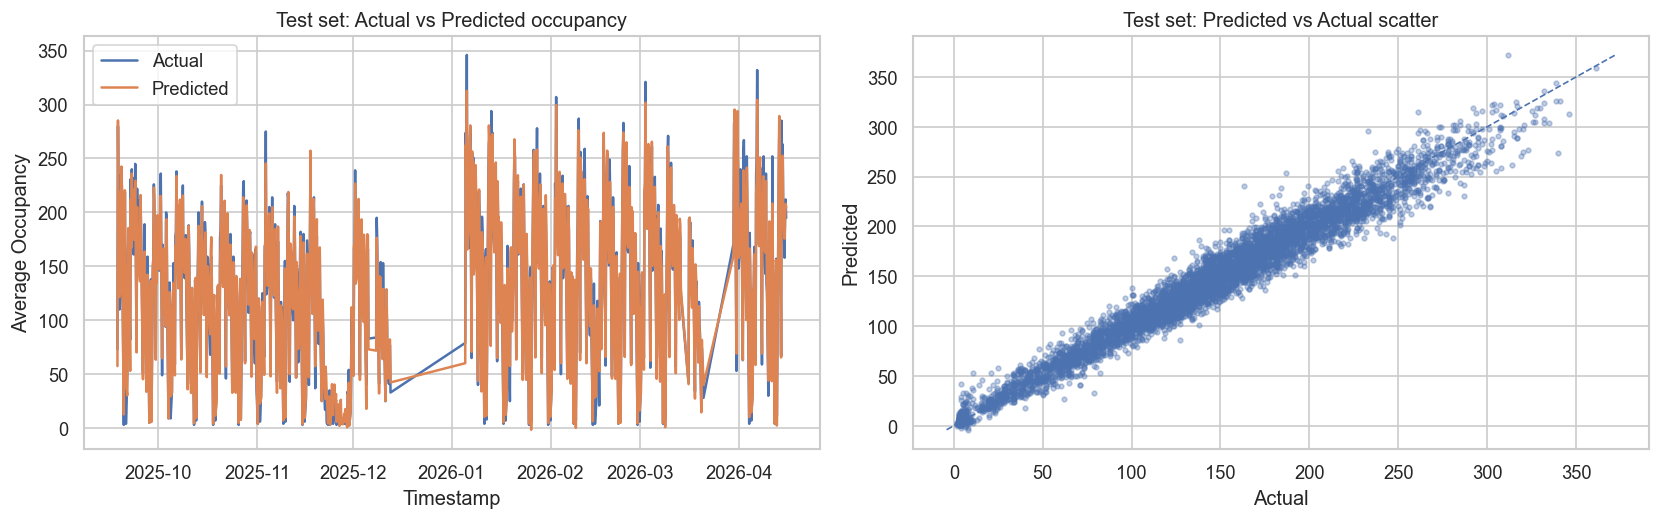

In [25]:
# Actual vs predicted on the 2025-26 test set
plot_df = pd.DataFrame({
    "Timestamp": df.loc[test_mask, "Timestamp"],
    "actual": y_test,
    "pred": pred,
}).sort_values("Timestamp")

# Downsample for readability in line chart
line_df = plot_df.iloc[::8].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(line_df["Timestamp"], line_df["actual"], label="Actual", linewidth=1.5)
axes[0].plot(line_df["Timestamp"], line_df["pred"], label="Predicted", linewidth=1.5)
axes[0].set_title("Test set: Actual vs Predicted occupancy")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Average Occupancy")
axes[0].legend()

axes[1].scatter(plot_df["actual"], plot_df["pred"], s=8, alpha=0.35)
min_v = min(plot_df["actual"].min(), plot_df["pred"].min())
max_v = max(plot_df["actual"].max(), plot_df["pred"].max())
axes[1].plot([min_v, max_v], [min_v, max_v], linestyle="--", linewidth=1)
axes[1].set_title("Test set: Predicted vs Actual scatter")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()

Residual mean: 0.2749654349689398
Residual std: 13.090546172675516


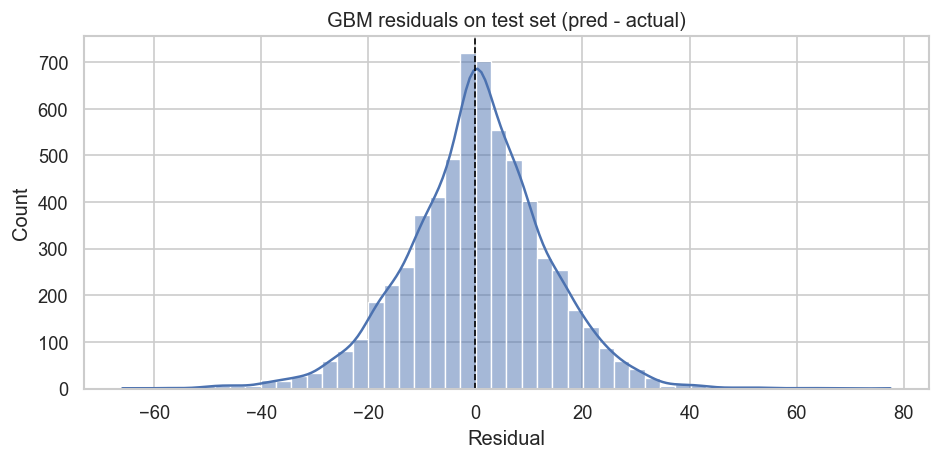

In [26]:
# Residual distribution on test
resid = plot_df["pred"] - plot_df["actual"]

plt.figure(figsize=(8, 4))
sns.histplot(resid, bins=50, kde=True)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("GBM residuals on test set (pred - actual)")
plt.xlabel("Residual")
plt.tight_layout()

print("Residual mean:", float(resid.mean()))
print("Residual std:", float(resid.std()))

/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/pycaret-env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/pycaret-env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/pycaret-env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,split,MAE,RMSE
0,train,8.183213,10.953509
1,val,10.569003,14.122453
2,test,9.962910,13.149058


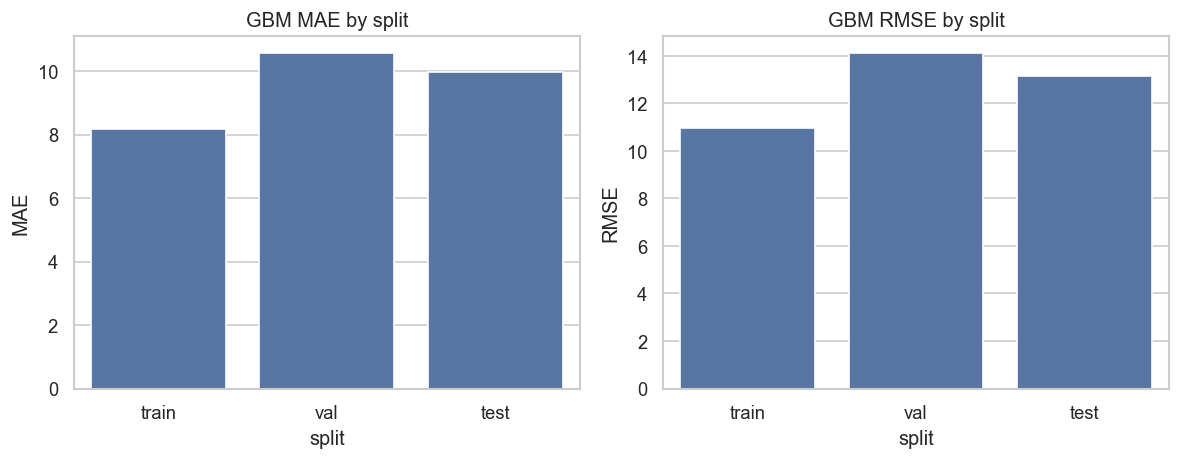

In [27]:
# Train/Val/Test error chart for GBM
# Validation split: 2024-25 Spring
val_mask = (df["academic_year"] == "2024-25") & (df["term"] == "Spring")
train_core_mask = train_mask & (~val_mask)

X_train_core = df.loc[train_core_mask, feature_cols]
y_train_core = df.loc[train_core_mask, target_col]
X_val = df.loc[val_mask, feature_cols]
y_val = df.loc[val_mask, target_col]

# Refit a model for clean train/val reporting
gbm_tv = Pipeline([
    ("preprocess", preprocess),
    ("model", HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.1,
        max_iter=200,
        random_state=RNG_SEED,
    )),
])

gbm_tv.fit(X_train_core, y_train_core)

pred_train_core = gbm_tv.predict(X_train_core)
pred_val = gbm_tv.predict(X_val)
pred_test_tv = gbm_tv.predict(X_test)

err_df = pd.DataFrame({
    "split": ["train", "val", "test"],
    "MAE": [
        mean_absolute_error(y_train_core, pred_train_core),
        mean_absolute_error(y_val, pred_val),
        mean_absolute_error(y_test, pred_test_tv),
    ],
    "RMSE": [
        mean_squared_error(y_train_core, pred_train_core, squared=False),
        mean_squared_error(y_val, pred_val, squared=False),
        mean_squared_error(y_test, pred_test_tv, squared=False),
    ],
})

display(err_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=err_df, x="split", y="MAE", ax=axes[0])
axes[0].set_title("GBM MAE by split")

sns.barplot(data=err_df, x="split", y="RMSE", ax=axes[1])
axes[1].set_title("GBM RMSE by split")

plt.tight_layout()

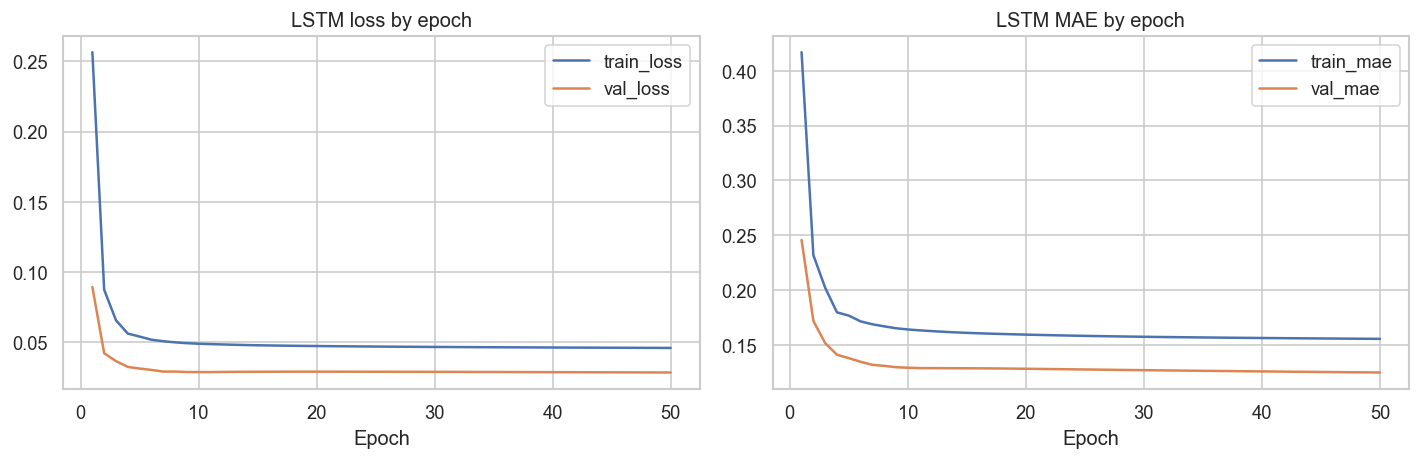

In [28]:
# LSTM train/validation curves (if TensorFlow ran)
if TF_AVAILABLE and "hist" in globals():
    h = pd.DataFrame(hist.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(h.index + 1, h["loss"], label="train_loss")
    if "val_loss" in h.columns:
        axes[0].plot(h.index + 1, h["val_loss"], label="val_loss")
    axes[0].set_title("LSTM loss by epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    if "mae" in h.columns:
        axes[1].plot(h.index + 1, h["mae"], label="train_mae")
    if "val_mae" in h.columns:
        axes[1].plot(h.index + 1, h["val_mae"], label="val_mae")
    axes[1].set_title("LSTM MAE by epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
else:
    print("LSTM history not available (TensorFlow section not run).")